# 05. XGBoost (eXtreme Gradient Boosting)

В этом ноутбуке:
- загрузка обработанных данных
- обучение базовой модели XGBoost с учётом дисбаланса (`scale_pos_weight`)
- подбор гиперпараметров с помощью RandomizedSearchCV (с early stopping)
- оценка качества на валидационной выборке
- подбор порога классификации по F1-мере
- построение матрицы ошибок, ROC-кривой и графика важности признаков
- сохранение модели, метрик и графиков

### 1. Загрузка данных

In [14]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import os

# Создаём папку для графиков этой модели
FIGURES_DIR = '../reports/figures/05_xgboost'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Загрузка обработанных данных
X_train = np.load('../data/processed/X_train_scaled.npy')
X_val = np.load('../data/processed/X_val_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')

feature_names = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse',
                 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
                 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер валидационной выборки: {X_val.shape[0]} строк")
print(f"Доля дефолтов в обучающей выборке: {y_train.mean():.4f}")
print(f"Доля дефолтов в валидационной выборке: {y_val.mean():.4f}")

Размер обучающей выборки: 119773 строк
Размер валидационной выборки: 29944 строк
Доля дефолтов в обучающей выборке: 0.0660
Доля дефолтов в валидационной выборке: 0.0660


### 2. Обучение базовой модели XGBoost

In [4]:
# Расчёт scale_pos_weight для учёта дисбаланса классов
# Рекомендуемое значение: количество негативных примеров / количество позитивных
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.4f}")

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_base.fit(X_train, y_train)
print("Базовая модель XGBoost обучена")

scale_pos_weight = 14.1573
Базовая модель XGBoost обучена


### 3. Оценка качества базовой модели

Precision: 0.2216
Recall:    0.6812
F1-score:  0.3344
ROC-AUC:   0.8435


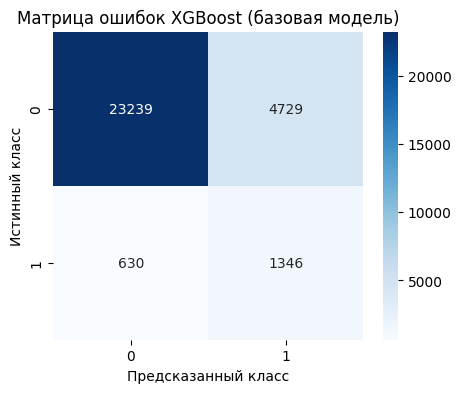

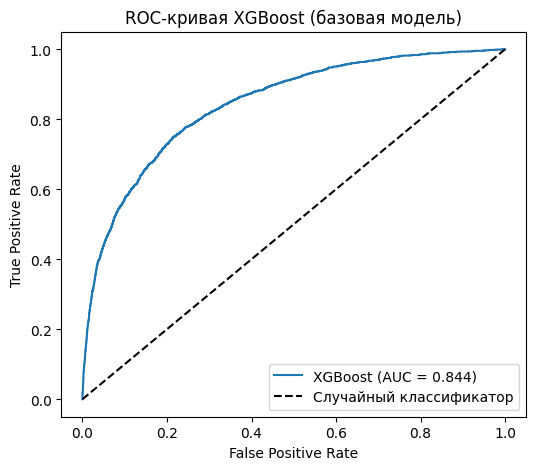

In [5]:
y_pred = xgb_base.predict(X_val)
y_pred_proba = xgb_base.predict_proba(X_val)[:, 1]

precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок XGBoost (базовая модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(FIGURES_DIR, 'xgb_confusion_matrix_base.png'), bbox_inches='tight')
plt.show()

# ROC-кривая
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая XGBoost (базовая модель)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'xgb_roc_curve_base.png'), bbox_inches='tight')
plt.show()

### 4. Подбор гиперпараметров (RandomizedSearchCV)

- Для ускорения используем случайный поиск по сетке параметров.
- Добавляем early stopping для автоматического определения оптимального числа деревьев.

In [6]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb_tune = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=10
)

random_search = RandomizedSearchCV(
    xgb_tune, param_dist, n_iter=30, cv=3, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)

# Для early stopping нужен eval_set
random_search.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Лучшие параметры: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Лучший ROC-AUC на кросс-валидации: 0.8635


### 5. Оценка модели с лучшими гиперпараметрами

Метрики оптимизированной модели:
Precision: 0.2134
Recall:    0.7713
F1-score:  0.3342
ROC-AUC:   0.8653


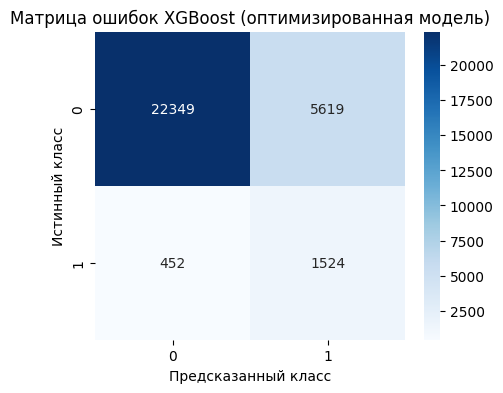

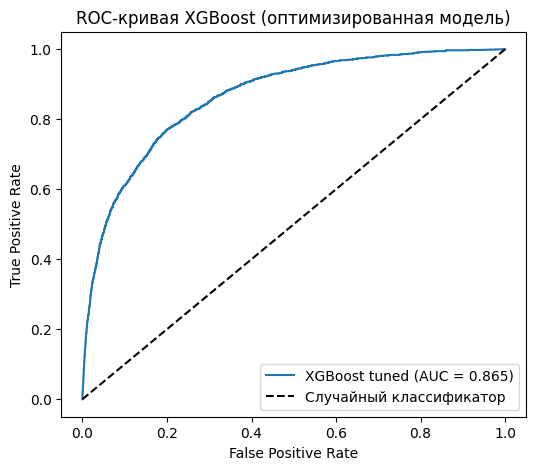

In [7]:
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_val)
y_pred_proba_best = best_xgb.predict_proba(X_val)[:, 1]

precision_best = precision_score(y_val, y_pred_best)
recall_best = recall_score(y_val, y_pred_best)
f1_best = f1_score(y_val, y_pred_best)
roc_auc_best = roc_auc_score(y_val, y_pred_proba_best)

print(f"Метрики оптимизированной модели:")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1-score:  {f1_best:.4f}")
print(f"ROC-AUC:   {roc_auc_best:.4f}")

# Матрица ошибок
cm_best = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок XGBoost (оптимизированная модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(FIGURES_DIR, 'xgb_confusion_matrix_tuned.png'), bbox_inches='tight')
plt.show()

# ROC-кривая
fpr_best, tpr_best, _ = roc_curve(y_val, y_pred_proba_best)
roc_auc_best_val = auc(fpr_best, tpr_best)

plt.figure(figsize=(6,5))
plt.plot(fpr_best, tpr_best, label=f'XGBoost tuned (AUC = {roc_auc_best_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая XGBoost (оптимизированная модель)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'xgb_roc_curve_tuned.png'), bbox_inches='tight')
plt.show()

In [33]:
# Экономическая оценка: расчёт для порога 0.3
threshold_03 = 0.3
y_pred_03 = (y_pred_proba_best >= threshold_03).astype(int)
tn_03, fp_03, fn_03, tp_03 = confusion_matrix(y_val, y_pred_03).ravel()
C_FN = 1.0
C_FP = 0.1
cost_03 = C_FP * fp_03 + C_FN * fn_03
print(f"Порог 0.3: FP = {fp_03}, FN = {fn_03}, потери = {cost_03:.0f}")

Порог 0.3: FP = 10478, FN = 200, потери = 1248


### 6. Визуализация важности признаков

<Figure size 1000x600 with 0 Axes>

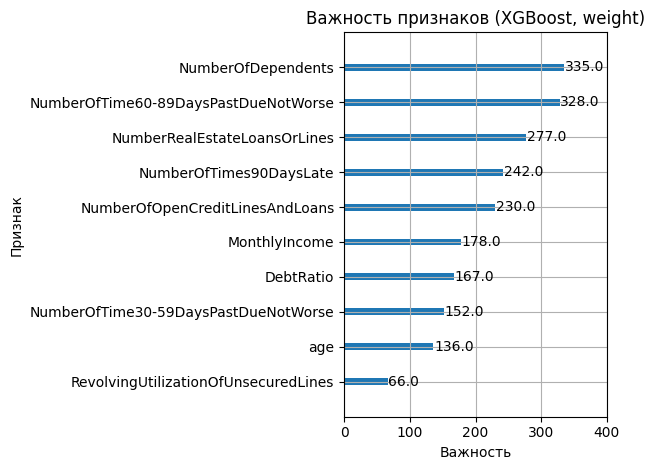

In [32]:
# График важности признаков (Feature Importance)
plt.figure(figsize=(10, 6))
ax = xgb.plot_importance(best_xgb, importance_type='weight', max_num_features=10, xlabel='Важность', ylabel='Признак')
plt.yticks(range(10), feature_names)
plt.title('Важность признаков (XGBoost, weight)')
ax.set_xlim(0, 400)  # принудительно установить правую границу в 400
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'xgb_feature_importance.png'), bbox_inches='tight')
plt.show()

### 7. Подбор порога классификации по F1-мере (для оптимизированной модели)

Лучший порог: 0.770
F1-score при этом пороге: 0.4385
После подбора порога (best=0.770):
Precision: 0.3878
Recall:    0.5046
F1-score:  0.4385


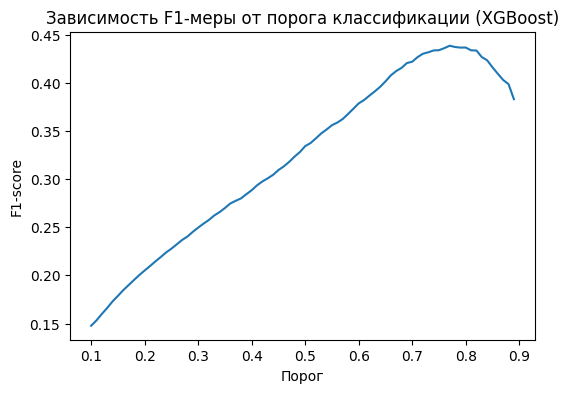

In [11]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val, y_pred_proba_best >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Лучший порог: {best_threshold:.3f}")
print(f"F1-score при этом пороге: {best_f1:.4f}")

# Применяем новый порог
y_pred_adj = (y_pred_proba_best >= best_threshold).astype(int)
precision_adj = precision_score(y_val, y_pred_adj)
recall_adj = recall_score(y_val, y_pred_adj)
f1_adj = f1_score(y_val, y_pred_adj)

print(f"После подбора порога (best={best_threshold:.3f}):")
print(f"Precision: {precision_adj:.4f}")
print(f"Recall:    {recall_adj:.4f}")
print(f"F1-score:  {f1_adj:.4f}")

# График зависимости F1 от порога
plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores)
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('Зависимость F1-меры от порога классификации (XGBoost)')
plt.savefig(os.path.join(FIGURES_DIR, 'xgb_f1_threshold.png'), bbox_inches='tight')
plt.show()

### 8. Вывод: сравнение базовой и оптимизированной моделей

In [12]:
print("Сравнение базовой и оптимизированной модели XGBoost:")
print(f"Базовая:      Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, AUC={roc_auc:.4f}")
print(f"Оптимизированная: Precision={precision_best:.4f}, Recall={recall_best:.4f}, F1={f1_best:.4f}, AUC={roc_auc_best:.4f}")

# Если улучшение есть, выбираем оптимизированную модель, иначе базовую
if roc_auc_best > roc_auc:
    xgb_final = best_xgb
    print("Финальная модель: оптимизированная (RandomizedSearchCV)")
else:
    xgb_final = xgb_base
    print("Финальная модель: базовая (улучшения нет)")

Сравнение базовой и оптимизированной модели XGBoost:
Базовая:      Precision=0.2216, Recall=0.6812, F1=0.3344, AUC=0.8435
Оптимизированная: Precision=0.2134, Recall=0.7713, F1=0.3342, AUC=0.8653
Финальная модель: оптимизированная (RandomizedSearchCV)


### 9. Сохранение модели, метрик и графиков

In [13]:
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Сохраняем финальную модель
with open(os.path.join(model_dir, 'xgboost.pkl'), 'wb') as f:
    pickle.dump(xgb_final, f)

# Сохраняем метрики в текстовый файл
with open(os.path.join(FIGURES_DIR, 'metrics.txt'), 'w', encoding='utf-8') as f:
    f.write("=== Базовые метрики ===\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-score:  {f1:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc:.4f}\n\n")
    
    f.write("=== Оптимизированная модель (RandomizedSearchCV) ===\n")
    f.write(f"Лучшие параметры: {random_search.best_params_}\n")
    f.write(f"Precision: {precision_best:.4f}\n")
    f.write(f"Recall:    {recall_best:.4f}\n")
    f.write(f"F1-score:  {f1_best:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc_best:.4f}\n\n")
    
    f.write("=== Подбор порога (по F1) ===\n")
    f.write(f"Лучший порог: {best_threshold:.3f}\n")
    f.write(f"Precision при лучшем пороге: {precision_adj:.4f}\n")
    f.write(f"Recall при лучшем пороге:    {recall_adj:.4f}\n")
    f.write(f"F1 при лучшем пороге:        {f1_adj:.4f}\n")

print("Модель и метрики сохранены")

Модель и метрики сохранены
